<a href="https://colab.research.google.com/drive/12oCVuhc9zNcLge8qDd09aL_G0cqNAf_o?usp=sharing" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CE 400/500: AI for Chemical Engineers
# Hands-on: Building an Agentic AI 1.0 for Autonomous Molecule Generation
Instructor: Kaihang Shi, Assistant Professor of Chemical & Biological Engineering at the University at Buffalo


**Learning objectives:**
- Build a simple agentic AI using Google Gemini to automatically generate a valid new molecule based on user's prompt.
- Learn how to integrate LLM with exisiting cheminformatics tools and ML models to accomplish sophisticated tasks with high fidelity


diagram.svg


**Referenes**:
- [Hands-on: Generating Drug-like Molecules Using Variational Autoencoder](https://colab.research.google.com/drive/1nHjR6AHeLn_tnKXk8yrSz2BroagaqmU6?usp=sharing)

## 0. Preparation
Let's install and load essential Python packages for this tutorial. These packages are necessary for invoking Gemini and handling SMILES and pre-trained variational autoencoder (VAE) models.

In [ ]:
# Install once per environment
!pip install rdkit SmilesPE

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 60.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 92.5 MB/s eta 0:00:00


In [ ]:
# Data handling and plotting helpers
import random
import numpy as np
import pandas as pd

# PyTorch implements the neural network building blocks
import torch

# Chemistry tools
from rdkit import Chem
from rdkit.Chem import Draw
from SmilesPE.pretokenizer import atomwise_tokenizer

# Fix the random seeds so every student sees the same behavior
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


## 1. Calling LLM from API

You are familiar with the web version of LLM (e.g. ChatGPT, Google Gemini). We can also directly call these LLM models using Python script. Let's see an example of calling Google's LLM:

In [ ]:
# To use the Gemini API, you'll need an API key. If you don't already have one, create a key in Google AI Studio.
# In Colab, add the key to the secrets manager under the "🔑" in the left panel. Give it the name `GOOGLE_API_KEY`. Then pass the key to the SDK:

# Import the Python SDK
import google.generativeai as genai
# Used to securely store your API key
from google.colab import userdata

try:
  GOOGLE_API_KEY=userdata.get('GOOGLE_API_KEY')
  genai.configure(api_key=GOOGLE_API_KEY)
except:
  pass

# Before you can make any API calls, you need to initialize the Generative Model.
gemini_model = genai.GenerativeModel('gemini-2.5-flash-preview-04-17')

# Now you can make API calls. For example, to generate a poem:
response = gemini_model.generate_content('Where is university at buffalo?')
print(response.text)

DefaultCredentialsError: 
  No API_KEY or ADC found. Please either:
    - Set the `GOOGLE_API_KEY` environment variable.
    - Manually pass the key with `genai.configure(api_key=my_api_key)`.
    - Or set up Application Default Credentials, see https://ai.google.dev/gemini-api/docs/oauth for more information.

With a Google Colab subscription, we can use Gemini without API key. In this tutorial, we will adopt this approach:

In [ ]:
from google.colab import ai

response = ai.generate_text("Where is university at buffalo?")
print(response)

The University at Buffalo (UB) is located in **Buffalo, New York**.

It actually has multiple campuses:

1.  **North Campus (Amherst, NY):** This is the largest and primary campus, located just north of the city of Buffalo in the town of Amherst. Most undergraduate programs, research facilities, and student residences are here.
2.  **South Campus (Buffalo, NY):** This is the historic campus, located within the city limits of Buffalo. It houses many of the health sciences schools (medicine, dentistry, nursing, public health, pharmacy).
3.  **Downtown Campus (Buffalo, NY):** This campus houses the Jacobs School of Medicine and Biomedical Sciences, as well as some other professional and research programs.

So, while its main mailing address and much of its activity are associated with Buffalo, its largest campus (North Campus) is technically in the neighboring town of **Amherst, New York**. It is the largest public university in the State University of New York (SUNY) system.


## 2. Set up VAE Models and Functions

This Agentic AI will leverage a pre-trained VAE model from our previous [hands-on tutorial](https://colab.research.google.com/drive/1nHjR6AHeLn_tnKXk8yrSz2BroagaqmU6?usp=sharing) to accomplish their goal. So let's set up essential parts here. You can find more details about following functions and variables in our previous hands-on tutorial.

In [ ]:
# download the pre-trained VAE model from VAE for drug discovery tutorial
!wget -O molecule_vae.pt "https://www.dropbox.com/scl/fi/kvqhdxmzbhvaci5500eni/molecule_vae.pt?rlkey=cycwsldvi43yuevqotv1bytl3&st=c0k6rvy5&dl=0"

# load Torch script VAE model
vae_model = torch.jit.load('molecule_vae.pt', map_location=device)
vae_model.eval()

--2025-11-09 05:41:26--  https://www.dropbox.com/scl/fi/kvqhdxmzbhvaci5500eni/molecule_vae.pt?rlkey=cycwsldvi43yuevqotv1bytl3&st=c0k6rvy5&dl=0
Resolving www.dropbox.com (www.dropbox.com)... 162.125.81.18, 2620:100:6031:18::a27d:5112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.81.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uc11d825f06f0d5a35c54d20b5b5.dl.dropboxusercontent.com/cd/0/inline/C02YIhko9wq6FPzWxIkZZSxQ-v-rXqRyJTqEt0VxQ0rM466Blxa1eKtUvmM3dMRT-4Huvf9MLcChaJBdV8K1IAZjvNJa7YcuecdrYGZFiG5v89uv7i-JgnZu6C_eaCTwKhAoz2j4W7fj-QrlNhXhlzOO/file# [following]
--2025-11-09 05:41:26--  https://uc11d825f06f0d5a35c54d20b5b5.dl.dropboxusercontent.com/cd/0/inline/C02YIhko9wq6FPzWxIkZZSxQ-v-rXqRyJTqEt0VxQ0rM466Blxa1eKtUvmM3dMRT-4Huvf9MLcChaJBdV8K1IAZjvNJa7YcuecdrYGZFiG5v89uv7i-JgnZu6C_eaCTwKhAoz2j4W7fj-QrlNhXhlzOO/file
Resolving uc11d825f06f0d5a35c54d20b5b5.dl.dropboxusercontent.com (uc11d825f06f0d5a35c54d20b5b5.dl.dropboxusercontent.com).

RecursiveScriptModule(
  original_name=MoleculeVAE
  (encoder): RecursiveScriptModule(
    original_name=Encoder
    (backbone): RecursiveScriptModule(
      original_name=Sequential
      (0): RecursiveScriptModule(original_name=Linear)
      (1): RecursiveScriptModule(original_name=ReLU)
    )
    (mu_layer): RecursiveScriptModule(original_name=Linear)
    (logvar_layer): RecursiveScriptModule(original_name=Linear)
  )
  (decoder): RecursiveScriptModule(
    original_name=Decoder
    (backbone): RecursiveScriptModule(
      original_name=Sequential
      (0): RecursiveScriptModule(original_name=Linear)
      (1): RecursiveScriptModule(original_name=ReLU)
      (2): RecursiveScriptModule(original_name=Linear)
      (3): RecursiveScriptModule(original_name=ReLU)
      (4): RecursiveScriptModule(original_name=Linear)
      (5): RecursiveScriptModule(original_name=ReLU)
    )
    (output_layer): RecursiveScriptModule(original_name=Linear)
  )
)

In [ ]:
vocab = ['<pad>', '<start>', '<end>', '#', '(', ')', '/', '1', '=', 'Br', 'C', 'Cl', 'F', 'I', 'N', 'O', 'P', 'S', '[C@@H]', '[C@@]', '[C@H]', '[C@]', '[N+]', '[N-]', '[NH+]', '[NH-]', '[NH2+]', '[NH3+]', '[O-]', '[P@@H]', '[P@@]', '[P@]', '[S-]', '[S@@]', '[S@]', '[n+]', '[n-]', '[nH+]', '[nH]', '\\', 'c', 'n', 'o', 's']
max_length = 60

token_to_idx = {token: idx for idx, token in enumerate(vocab)}
idx_to_token = {idx: token for token, idx in token_to_idx.items()}

In [ ]:
# Define a function to convert SMILES to one-hot encoding
def smiles_to_one_hot(smiles):

    # prepend/append boundary markers
    tokens = ['<start>'] + atomwise_tokenizer(smiles) + ['<end>']
    if len(tokens) <= max_length:
        # pad with <pad> so all sequences share the same length
        tokens += ['<pad>'] * (max_length - len(tokens))
    else:
        # raise an error
        raise ValueError("max_length exceeded")

    # Create a one-hot matrix
    onehot = np.zeros((len(vocab), max_length), dtype=np.float32)
    for i, token in enumerate(tokens):
        idx = token_to_idx.get(token)
        onehot[idx, i] = 1.0

    # return flattened 1D vector (row by row)
    return onehot.flatten()

# Define a function to convert one-hot flattened vector back to SMILES
def one_hot_to_smiles(flat_onehot):

    # convert torch tensors to numpy
    if isinstance(flat_onehot, torch.Tensor):
        vec = flat_onehot.detach().cpu().numpy().ravel()
    else:
        vec = np.asarray(flat_onehot).ravel()

    # reshape flattened vector back to (vocab_size, max_length) matrix
    onehot_mat = vec.reshape(len(vocab), max_length)
    # get indices of max value (1) along each column/token
    indices = np.argmax(onehot_mat, axis=0).astype(int).tolist()

    # decode indices into tokens
    tokens = []
    for idx in indices:
        token = idx_to_token.get(int(idx))
        if token == '<end>':
            break
        if token in ('<pad>', '<start>'):
            continue
        tokens.append(token)

    return ''.join(tokens)


# Encode the anchor SMILES with the pretrained TorchScript encoder
def encode_smiles(smiles):
    vec = smiles_to_one_hot(smiles)
    # Add a batch dimension and move data onto the active device
    tensor = torch.from_numpy(vec).float().unsqueeze(0).to(device)
    with torch.no_grad():
        # Encoder outputs the latent mean and log-variance for the molecule
        mu, logvar = vae_model.encoder(tensor)
    return mu, logvar

# Decode a latent vector back into a SMILES string
def decode_latent(z):
    with torch.no_grad():
        x_hat = vae_model.decoder(z)
    return one_hot_to_smiles(x_hat.squeeze(0))


## 3. Gemini-Powered Molecule Agent
This simple agent uses Google Gemini to translate a natural-language request into a SMILES anchor, samples nearby points in the VAE latent space, and decides if to continue the search based on validity check results from RDKit.


In [ ]:
# Turn a natural-language request into a usable anchor SMILES
def get_anchor_smiles(user_prompt):
    user_prompt = user_prompt.strip()
    request = (
        'Translate the molecule in following user request into a SMILES string.\n'
        'Return only the SMILES string without commentary.'
    )
    # Ask Gemini to respond with only a SMILES candidate for the prompt
    response = ai.generate_text(request + '\nUser request: ' + user_prompt)
    # return SMILES of user specified molecule
    return response

In [ ]:
# Define the "brain" of your agent.
def generate_similar_molecule_agentic(user_prompt, base_radius=0.05, max_attempts=30, growth=1.5):

    # Use Gemini to get SMILES of user specified molecule
    anchor_smiles = get_anchor_smiles(user_prompt)
    print('Anchor SMILES:', anchor_smiles)
    mu, logvar = encode_smiles(anchor_smiles)
    std = torch.exp(0.5 * logvar)
    radius = base_radius

    # This prompt forces the LLM to act as a planner and choose a "tool" or "command".
    PLANNING_PROMPT = """
    You are a molecule generation agent. Your goal is to find a new, valid molecule.
    Based on the last attempt, you must choose the next action.
    Your *only* output must be one of the following commands:

    1.  `ACCEPT`: The molecule is valid.
    2.  `RETRY`: The molecule was invalid. Try again.
    3.  `WIDEN`: We have failed several times. Widen the search radius to explore new areas.

    Here is the current state:
    Goal: Find a molecule similar to {anchor_smiles}
    Attempt: {attempt} / {max_attempts}
    Current Radius: {radius:.2f}

    Last Candidate: {candidate}
    Valid Molecule: {is_valid}

    What is your next action? Choose only `ACCEPT`, `RETRY`, or `WIDEN`.
    """

    # --- This is now an agent loop ---
    for attempt in range(1, max_attempts + 1):

        # 1. ACT (Generate a candidate)
        noise = torch.randn_like(std) * radius
        z = mu + noise * std
        candidate = decode_latent(z)

        # 2. OBSERVE (Use tools to check the candidate)
        mol = Chem.MolFromSmiles(candidate)
        is_valid = mol is not None

        print(f"--- Attempt {attempt} ---")
        print(f"Candidate: {candidate} (Valid: {is_valid})")

        # 3. REFLECT & PLAN (Ask the LLM to decide what to do next)
        # The format() method for a string allows the insertion of values
        #   into a template string and controlling their presentation.
        prompt = PLANNING_PROMPT.format(
            anchor_smiles=anchor_smiles,
            attempt=attempt,
            max_attempts=max_attempts,
            radius=radius,
            candidate=candidate,
            is_valid=is_valid
        )

        print(prompt)
        response = ai.generate_text(prompt)
        decision = response.strip().upper()

        print(f"LLM Decision: {decision}")

        # 4. ACT (Execute the LLM's chosen action)
        if decision == 'ACCEPT':
            # return newly generated molecule
            return mol

        elif decision == 'WIDEN':
            radius *= growth
            print(f"Search radius increased to {radius:.2f}")

        elif decision == 'RETRY':
            # Just continue to the next loop iteration
            # If there are more tools that LLM can use to improve the results, you can put them here and
            #   let LLM decide the best tool to choose by themselves.
            pass

        else:
            print(f"Warning: LLM gave unknown command '{decision}'. Defaulting to RETRY.")
            pass # Default to retrying

    RuntimeError('Failed to sample a valid molecule. Try increasing max_attempts or base_radius.')

Now let's try this simple AI agent:

Anchor SMILES: Cc1ccccc1
--- Attempt 1 ---
Candidate: Cc1ccccc1C (Valid: True)

    You are a molecule generation agent. Your goal is to find a new, valid molecule.
    Based on the last attempt, you must choose the next action.
    Your *only* output must be one of the following commands:

    1.  `ACCEPT`: The molecule is valid.
    2.  `RETRY`: The molecule was invalid. Try again.
    3.  `WIDEN`: We have failed several times. Widen the search radius to explore new areas.

    Here is the current state:
    Goal: Find a molecule similar to Cc1ccccc1
    Attempt: 1 / 30
    Current Radius: 0.05

    Last Candidate: Cc1ccccc1C
    Valid Molecule: True

    What is your next action? Choose only `ACCEPT`, `RETRY`, or `WIDEN`.
    
LLM Decision: ACCEPT


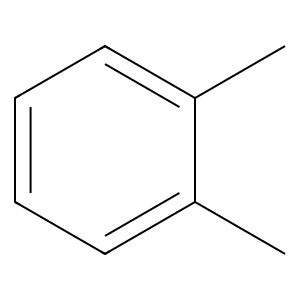

In [ ]:
# Quick demo
demo_prompt = 'please generate a similar molecule to benzene'

# Run the agent and visualize the generated molecule
candidate = generate_similar_molecule_agentic(demo_prompt)
Draw.MolToImage(candidate)
